In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [ ]:
# Load the data
users = pd.read_csv('data/userbase.csv')
sent = pd.read_csv('data/sent_emails.csv')
responded = pd.read_csv('data/responded.csv')

print("Userbase shape:", users.shape)
print("Sent emails shape:", sent.shape)
print("Responded shape:", responded.shape)

In [ ]:
#Explore the Data
print("=== USERBASE ===")
print(users.head())
print()
print(users.info())
print()

print("=== SENT EMAILS ===")
print(sent.head())
print()

print("=== RESPONDED ===")
print(responded.head())

In [ ]:
#Calculate Open Rates

#count how many emails were sent per subject line
sent_counts = sent.groupby('SubjectLine_ID').size().reset_index(name='emails_sent')

#count how many responses per subject line
responded_counts = responded.groupby('SubjectLine_ID').size().reset_index(name='emails_responded')

#merge the two together
summary = sent_counts.merge(responded_counts, on='SubjectLine_ID')

#calculate open rate as a percentage
summary['open_rate'] = (summary['emails_responded'] / summary['emails_sent']) * 100

print(summary)

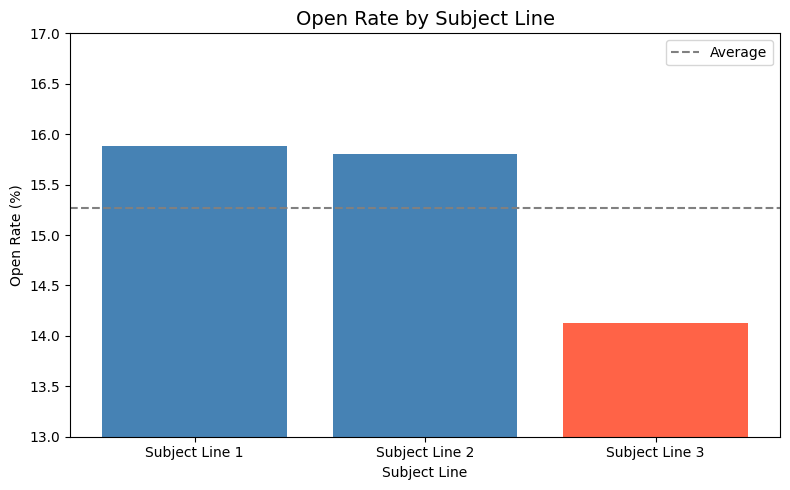

In [7]:
#Visualize Open Rates
plt.figure(figsize=(8, 5))
plt.bar(['Subject Line 1', 'Subject Line 2', 'Subject Line 3'],
        summary['open_rate'],
        color=['steelblue', 'steelblue', 'tomato'])

plt.title('Open Rate by Subject Line', fontsize=14)
plt.xlabel('Subject Line')
plt.ylabel('Open Rate (%)')
plt.ylim(13, 17)
plt.axhline(y=summary['open_rate'].mean(), color='gray', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.show()